In [1]:
#Copyright 2026 Mücahit Sahin
#
#Licensed under the Apache License, Version 2.0 (the "License");
#you may not use this file except in compliance with the License.
#You may obtain a copy of the License at
#
#    http://www.apache.org/licenses/LICENSE-2.0
#
#Unless required by applicable law or agreed to in writing, software
#distributed under the License is distributed on an "AS IS" BASIS,
#WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#See the License for the specific language governing permissions and
#limitations under the License.

In [2]:
import pandas as pd
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

from utils import metrics
from utils import sortinghat_featurization

/opt/anaconda/envs/test/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator CountVectorizer from version 0.22.2.post1 when using version 1.4.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


# Reproduce SortingHat results with provided train and test split

## Train

In [3]:
train = pd.read_csv("data/Benchmark-Labeled-Data/data_train.csv")
train.head()

,Record_id,Attribute_name,y_act,total_vals,num_nans,%_nans,num_of_dist_val,%_dist_val,mean,std_dev,...,mean_stopword_total,stdev_stopword_total,mean_char_count,stdev_char_count,mean_whitespace_count,stdev_whitespace_count,mean_delim_count,stdev_delim_count,is_list,is_long_sentence
0,33,Area,categorical,21477,0,0.0,174,0.810169,0.000000,0.000000,...,0.2,0.4,10.0,4.816638,0.4,0.8,0.4,0.8,False,False
1,33,Area Code,categorical,21477,0,0.0,174,0.810169,125.449411,72.866452,...,0.0,0.0,1.0,0.000000,0.0,0.0,0.0,0.0,False,False
2,33,Element,categorical,21477,0,0.0,2,0.009312,0.000000,0.000000,...,0.0,0.0,4.0,0.000000,0.0,0.0,0.0,0.0,False,False
3,33,Element Code,categorical,21477,0,0.0,2,0.009312,5211.687154,146.816661,...,0.0,0.0,4.0,0.000000,0.0,0.0,0.0,0.0,False,False
4,33,Item,categorical,21477,0,0.0,115,0.535457,0.000000,0.000000,...,0.8,0.4,19.6,2.244994,2.0,0.0,2.0,0.0,False,False


In [4]:
y_train = train['y_act']
le = LabelEncoder()
y_train = le.fit_transform(y_train)

In [5]:
train = sortinghat_featurization.FeatureExtraction(train)

In [6]:
# new columns are int, make all strings to escape error from model.fit
train.columns = train.columns.astype(str)

In [7]:
X_train = train

In [8]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [9]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Test

In [10]:
test = pd.read_csv("data/Benchmark-Labeled-Data/data_test.csv")
test.head()

,Record_id,Attribute_name,y_act,total_vals,num_nans,%_nans,num_of_dist_val,%_dist_val,mean,std_dev,...,mean_stopword_total,stdev_stopword_total,mean_char_count,stdev_char_count,mean_whitespace_count,stdev_whitespace_count,mean_delim_count,stdev_delim_count,is_list,is_long_sentence
0,285,Net Income-Cont. Operations,numeric,1781,0,0.000000,1693,95.058956,1.748059e+09,4.333643e+09,...,0.0,0.0,10.2,0.748331,0.0,0.0,0.0,0.0,False,False
1,285,Earnings Before Interest and Tax,numeric,1781,0,0.000000,1717,96.406513,2.710102e+09,6.143620e+09,...,0.0,0.0,10.2,0.748331,0.0,0.0,0.0,0.0,False,False
2,353,expense_OtherInvestments,numeric,2720,2685,98.713235,35,1.286765,-4.665556e+04,1.694200e+05,...,0.0,0.0,5.8,1.469694,0.0,0.0,0.0,0.0,False,False
3,352,FairValueChange_SecLendUG,numeric,2720,2685,98.713235,35,1.286765,-4.764415e+03,1.333107e+05,...,0.0,0.0,7.6,2.497999,0.0,0.0,0.0,0.0,False,False
4,352,expense_SurvivorBenefits,numeric,2720,2418,88.897059,297,10.919118,-3.379214e+04,4.120279e+04,...,0.0,0.0,5.4,1.200000,0.0,0.0,0.0,0.0,False,False


In [11]:
y_test = test['y_act']
y_test = le.transform(y_test)

In [12]:
test = sortinghat_featurization.FeatureExtraction(test)

In [13]:
# new columns are int, make all strings to escape error from model.fit
test.columns = test.columns.astype(str)

In [14]:
X_test = test

In [15]:
pred_test = model.predict(X_test)

In [16]:
class_map = dict(zip(le.transform(le.classes_), le.classes_))

In [17]:
# revert classes back to strings
y_test = le.inverse_transform(y_test)
pred_test = le.inverse_transform(pred_test)

######### General model performance #########

F1-Score: 0.915
Precision: 0.936
Recall: 0.899
Accuracy: 0.933

######### Binarization Metrics #########

## Class: categorical ##

F1-Score: 0.939
Precision: 0.924
Recall: 0.954
Accuracy: 0.971

////////////////////////////////////////

## Class: context-specific ##

F1-Score: 0.788
Precision: 0.85
Recall: 0.735
Accuracy: 0.963

////////////////////////////////////////

## Class: datetime ##

F1-Score: 0.989
Precision: 0.993
Recall: 0.986
Accuracy: 0.998

////////////////////////////////////////

## Class: embedded-number ##

F1-Score: 0.934
Precision: 0.939
Recall: 0.929
Accuracy: 0.993

////////////////////////////////////////

## Class: list ##

F1-Score: 0.863
Precision: 0.978
Recall: 0.772
Accuracy: 0.993

////////////////////////////////////////

## Class: not-generalizable ##

F1-Score: 0.921
Precision: 0.925
Recall: 0.916
Accuracy: 0.983

////////////////////////////////////////

## Class: numeric ##

F1-Score: 0.968
Precision: 0.

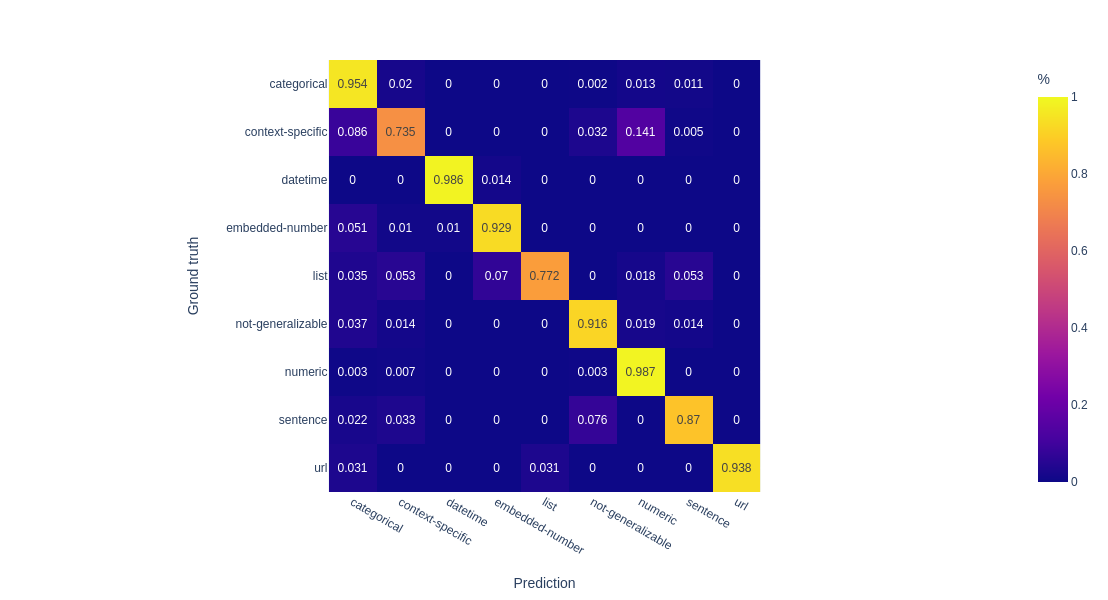

In [18]:
metrics.model_performance(y_test, pred_test, class_map, decimal_places=3, class_average='macro')
metrics.binary_metrics(y_test, pred_test, class_map, decimal_places=3)
metrics.plot_heatmap(y_test, pred_test, class_map, decimal_places=3)